# Reading provenance directly
The processed RO-Crates contain a new directory with provenance data
We can extract provenance data directly without reading Galaxy entities:
```
exp_crate/
|-- datasets/
|   |-- ds_001.xxx
|   `-- ...
|-- provenance/
|   |-- galaxy_run_prov.jsonld
|   |-- galaxy_run_prov.ttl
|   `-- ...
|-- workflow/
|--ro-crate-metadata.json
...        

In [1]:
# using rocrate
from rocrate.rocrate import ROCrate
from pathlib import Path

# defined functions to get data from RO-Crate
from read_provenance import *

file_name = "FeS2-Analysis.rocrate.prov.zip"

file_path = Path("./result_roc", file_name)

crate = ROCrate(file_path)
data_entities = []
for e in crate.get_entities():
    if "provenance/data" in e.id:
        print(e.id, e.type)
        data_entities.append(e.id)
        

C:\Users\scman1\AppData\Roaming\Python\Python39\site-packages\rocrate\vocabs.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


provenance/dataset_df0bac1ee137448a.jsonld File
provenance/dataset_df02c7af9dfe5b62.jsonld File
provenance/dataset_d49ffa4044c67d15.jsonld File
provenance/dataset_6c2ea4582a260280.jsonld File
provenance/dataset_409c0d24534294d8.jsonld File
provenance/dataset_a38f4b5b93cd4e1a.jsonld File
provenance/dataset_a011be860e2a8b79.jsonld File
provenance/dataset_547228271cdb66e2.jsonld File
provenance/dataset_75738551921d866c.jsonld File
provenance/dataset_c3e4da2bb600d6e3.jsonld File
provenance/dataset_a9305118c6acc078.jsonld File
provenance/dataset_fb5bc774c9b03fce.jsonld File


In [2]:
f = get_file_from_rocratezip(file_path, data_entities[0])
details = json.load(f)

In [3]:
print(json.dumps(details, indent=4))

{
    "@context": {
        "cdifprov": "https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#",
        "dcterms": "http://purl.org/dc/terms/",
        "ex": "http://example.org#",
        "panet": "http://purl.org/pan-science/PaNET/",
        "prov": "http://www.w3.org/ns/prov#",
        "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
        "schema": "https://schema.org/",
        "skos": "http://www.w3.org/2004/02/skos/core#",
        "sostdp": "http://sweetontology.net/propOrdinal/ProcessingLevel/"
    },
    "@id": "dataset_df0bac1ee137448a.jsonld",
    "@type": [
        "prov:Entity",
        "cdifprov:Dataset",
        "schema:MediaObject",
        "schema:CreativeWork"
    ],
    "dcterms:description": "uploaded txt file",
    "dcterms:format": "text/plain",
    "dcterms:subject": [
        {
            "@id": "panet:PaNET01196"
        },
        {
            "@id": "ex:Level0"
        }
    ],
    "prov:wasAttributedTo": [
        {
            "@id": "/srv/g

In [4]:
def get_roc_provenance(roc_file):
    roc_graph = Graph()
    f = get_file_from_rocratezip(roc_file, "provenance/galaxy_run_prov.jsonld")
    json_roc = json.load(f)
    roc_graph.parse(
        data=json.dumps(json_roc),
        format="json-ld",publicID="/"
    )
    roc_graph = fix_graph_root(roc_graph)
    return roc_graph
    
def fix_graph_root(a_graph):
    new_graph = Graph()
    
    for s, p, o in a_graph:    
        if isinstance(s, URIRef) and str(s).startswith("file:///"):
            s = URIRef(str(s).replace("file://", "", 1))
        if isinstance(o, URIRef) and str(o).startswith("file:///"):
            o = URIRef(str(o).replace("file://", "", 1))
        new_graph.add((s, p, o))
    return new_graph

an_roc_graph = get_roc_provenance(file_path)

In [5]:
#get datasets provenance from the roc graph
datasets_provenance = get_datasets_prov(an_roc_graph)
display(HTML(datasets_provenance.to_html().replace("\\n","<br>")))

,Step,Activity,Tool,Dataset,Inputs
0,/step/0,fetch data from history,DATA_FETCH,fes2_rt01_mar02.xmu,None
1,/step/1,fetch data from history,DATA_FETCH,1564889.cif,None
2,/step/2,process and normalise XAS,larch_athena,FeS2_plot,fes2_rt01_mar02.xmu
3,/step/2,process and normalise XAS,larch_athena,FeS2_athena,fes2_rt01_mar02.xmu
4,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF paths of 1564889.cif,1564889.cif
5,/step/3,calculate FEFF paths from crystal,larch_feff,CSV summary of 1564889.cif,1564889.cif
6,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF input of 1564889.cif,1564889.cif
7,/step/4,select FEFF paths,larch_select_paths,fes2_gds,"CSV summary of 1564889.cif, FEFF paths of 1564889.cif"
8,/step/4,select FEFF paths,larch_select_paths,fes2_sp,"CSV summary of 1564889.cif, FEFF paths of 1564889.cif"
9,/step/5,FEFF fit of XAS,larch_artemis,fit_report_FeS2,"FeS2_athena, FEFF paths of 1564889.cif, fes2_gds, fes2_sp"


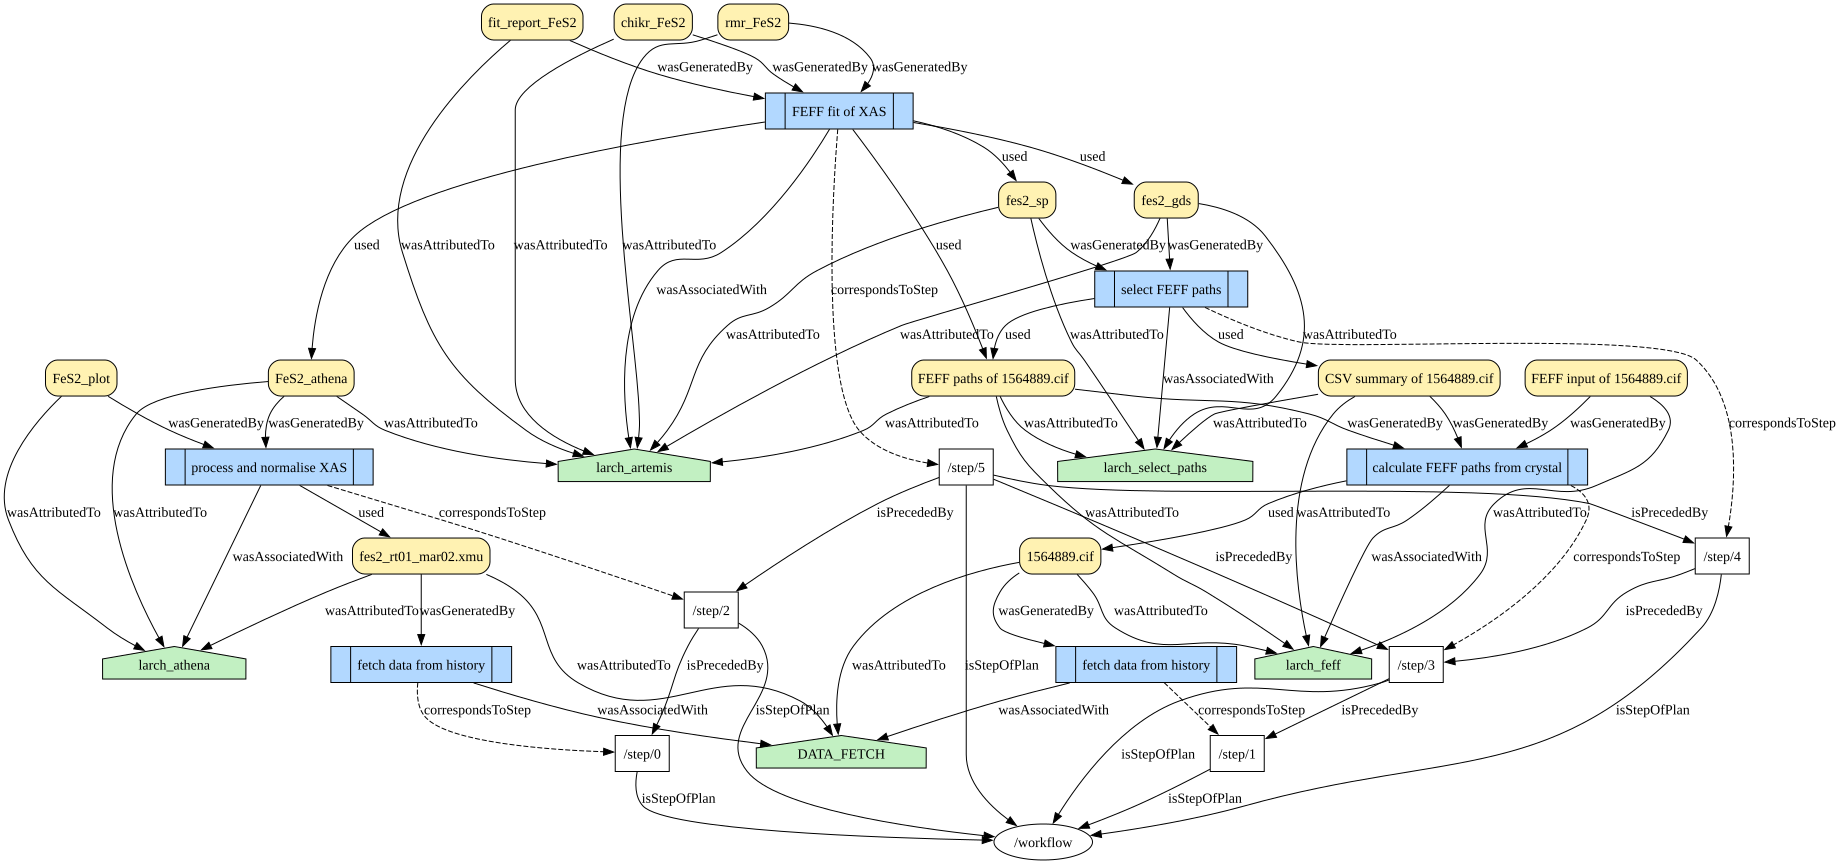

In [6]:
#plan_dot = draw_prov_only(an_roc_graph)
#display(plan_dot)

#plan_dot = draw_pplan_only(an_roc_graph)
#display(plan_dot)

fullprov_dot = draw_prov_full(an_roc_graph)
display(fullprov_dot)

In [7]:
ds_jsons = show_datasets(an_roc_graph, output_path = "", show_only = True)

,Property,Value
0,dcterms:format,text/plain
1,prov:wasAttributedTo,DATA_FETCH
2,prov:wasAttributedTo,larch_athena
3,prov:wasGeneratedBy,fetch data from history
4,dcterms:description,uploaded txt file
5,skos:prefLabel,fes2_rt01_mar02.xmu
6,rdf:type,schema:MediaObject
7,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
8,rdf:type,prov:Entity
9,schema:id,datasets/fes2_rt01_mar02.xmu_df0bac1ee137448a.txt


,Property,Value
0,skos:prefLabel,1564889.cif
1,rdf:type,schema:MediaObject
2,rdf:type,prov:Entity
3,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
4,prov:wasAttributedTo,larch_feff
5,prov:wasAttributedTo,DATA_FETCH
6,prov:wasGeneratedBy,fetch data from history
7,dcterms:format,chemical/x-cif
8,schema:id,datasets/1564889.cif_df02c7af9dfe5b62.cif
9,dcterms:description,"Metadata is limited as the Atomic Simulation Environment (ASE) is not installed.You can still use this dataset in tools and workflows.For full metadata, ask your admin to install the 'ase' Python package."


,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
1,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
2,rdf:type,schema:MediaObject
3,rdf:type,prov:Entity
4,schema:id,datasets/FeS2_plot_6c2ea4582a260280.png
5,skos:prefLabel,FeS2_plot
6,prov:wasGeneratedBy,process and normalise XAS
7,prov:wasAttributedTo,larch_athena
8,dcterms:description,"Attempting to read from /mnt/nfs/data/f/6/4/dataset_f640df2f-ce68-4309-bc83-2e052fb749f1.datRead columns: ['energy', 'xmu', 'i0']'energy' present in column headersRenaming columns to: ['energy', 'mu', 'i0']Cannot load group.athena_params.bkg from gro"
9,dcterms:format,image/png


,Property,Value
0,dcterms:format,application/vnd.demeter.athena
1,dcterms:description,atsym: Febkg_e0: 7117.0edge: Knpts: 352xmax: 7963.5xmin: 6911.8
2,schema:id,datasets/FeS2_athena_d49ffa4044c67d15.prj
3,rdf:type,schema:MediaObject
4,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
5,rdf:type,prov:Entity
6,prov:wasGeneratedBy,process and normalise XAS
7,skos:prefLabel,FeS2_athena
8,prov:wasAttributedTo,larch_artemis
9,prov:wasAttributedTo,larch_athena


,Property,Value
0,prov:wasAttributedTo,larch_artemis
1,prov:wasAttributedTo,larch_select_paths
2,prov:wasAttributedTo,larch_feff
3,rdf:type,schema:MediaObject
4,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
5,rdf:type,prov:Entity
6,skos:prefLabel,FEFF paths of 1564889.cif
7,schema:id,datasets/FEFF_paths_of_1564889.cif_a011be860e2a8b79.zip
8,prov:wasGeneratedBy,calculate FEFF paths from crystal
9,dcterms:description,Parsing dataset_0c058fb5-124f-4a1e-820a-643ff322c47a.dat and saving to feff/feff.inp*** feff input generated by xraylarch cif2feff using pymatgen ***TITLE Formula: FeS2TITLE SpaceGroup: PnnmTITLE # sites: 6* crystallographics sites: note that


...

,Property,Value
0,prov:wasAttributedTo,larch_select_paths
1,prov:wasAttributedTo,larch_artemis
2,prov:wasGeneratedBy,select FEFF paths
3,skos:prefLabel,fes2_gds
4,dcterms:format,text/csv
5,rdf:type,schema:MediaObject
6,rdf:type,prov:Entity
7,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
8,schema:id,datasets/fes2_gds_547228271cdb66e2.gds
9,dcterms:description,


,Property,Value
0,prov:wasAttributedTo,larch_select_paths
1,prov:wasAttributedTo,larch_artemis
2,dcterms:format,text/csv
3,prov:wasGeneratedBy,select FEFF paths
4,rdf:type,schema:MediaObject
5,rdf:type,prov:Entity
6,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
7,skos:prefLabel,fes2_sp
8,dcterms:description,
9,schema:id,datasets/fes2_sp_75738551921d866c.sp


,Property,Value
0,prov:wasGeneratedBy,FEFF fit of XAS
1,rdf:type,schema:MediaObject
2,rdf:type,prov:Entity
3,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
4,prov:wasAttributedTo,larch_artemis
5,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
6,schema:id,datasets/fit_report_FeS2_a9305118c6acc078.feffit
7,dcterms:format,text/plain
8,skos:prefLabel,fit_report_FeS2
9,dcterms:subject,<http://purl.org/pan-science/PaNET/PaNET01197>


,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
1,rdf:type,schema:MediaObject
2,rdf:type,prov:Entity
3,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
4,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
5,prov:wasGeneratedBy,FEFF fit of XAS
6,prov:wasAttributedTo,larch_artemis
7,dcterms:format,image/png
8,schema:id,datasets/rmr_FeS2_fb5bc774c9b03fce.png
9,skos:prefLabel,rmr_FeS2


,Property,Value
0,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
1,prov:wasGeneratedBy,FEFF fit of XAS
2,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
3,rdf:type,schema:MediaObject
4,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
5,rdf:type,prov:Entity
6,prov:wasAttributedTo,larch_artemis
7,schema:id,datasets/chikr_FeS2_c3e4da2bb600d6e3.png
8,skos:prefLabel,chikr_FeS2
9,dcterms:format,image/png


In [8]:
from collections import Counter
from rdflib import RDF, Namespace

PROV = Namespace("http://www.w3.org/ns/prov#")
entities = set(an_roc_graph.subjects(RDF.type, PROV.Entity))

types = Counter()
formats = Counter()
subjects = Counter()
for e in entities:
    # entity types
    for t in an_roc_graph.objects(e, RDF.type):
        if t != PROV.Entity:
            types[str(t).split("/")[-1]] += 1

    # file formats
    for f in an_roc_graph.objects(e, DCTERMS.format):
        formats[str(f)] += 1

    # file subjects
    for d in an_roc_graph.objects(e, DCTERMS.description):
        print("*"*80)
        print(e)
        print(d)
        #subjects[str(s)] += 1

print("Total entities:", len(entities))

print("\nTypes")
for k, v in types.most_common():
    print(f"{k}: {v}")

print("\nFormats")
for k, v in formats.most_common():
    print(f"{k}: {v}")
    
print("\nSubjects")
for k, v in subjects.most_common():
    print(f"{k}: {v}")

********************************************************************************
/dataset/c3e4da2bb600d6e3

Archive:  /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat
   creating: feff/
  inflating: feff/feff.inp
  inflating: feff/feffrun_feff6l.log
  inflating: feff/feff.run
  inflating: feff/misc.dat
  inflating: feff/phase.bin
  inflatin
********************************************************************************
/dataset/fb5bc774c9b03fce

Archive:  /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat
   creating: feff/
  inflating: feff/feff.inp
  inflating: feff/feffrun_feff6l.log
  inflating: feff/feff.run
  inflating: feff/misc.dat
  inflating: feff/phase.bin
  inflatin
********************************************************************************
/dataset/75738551921d866c

********************************************************************************
/dataset/547228271cdb66e2

**********************************************************

In [9]:
# if input (DATAFETCH) and type text: look for header and find keywords (element, edge, e0, sample)
for e in entities:
    # entity types
    for ag in an_roc_graph.objects(e, PROV.wasAttributedTo):
        for lbl in an_roc_graph.objects(ag, RDFS.label):
            if 'DATA_FETCH' in lbl:
                for t in an_roc_graph.objects(e, DCTERMS.format):
                    for ag in an_roc_graph.objects(e, PROV.wasAttributedTo):
                        print (e, "attributed to", lbl, " -> ", ag)
                        print(t)

/dataset/df02c7af9dfe5b62 attributed to DATA_FETCH  ->  /srv/galaxy/var/shed_tools/toolshed.g2.bx.psu.edu/repos/muon-spectroscopy-computational-project/larch_feff/larch_feff/0.9.75+galaxy0
chemical/x-cif
/dataset/df02c7af9dfe5b62 attributed to DATA_FETCH  ->  /srv/galaxy/server/data_fetch.py
chemical/x-cif
/dataset/df0bac1ee137448a attributed to DATA_FETCH  ->  /srv/galaxy/server/data_fetch.py
text/plain
/dataset/df0bac1ee137448a attributed to DATA_FETCH  ->  /srv/galaxy/var/shed_tools/toolshed.g2.bx.psu.edu/repos/muon-spectroscopy-computational-project/larch_athena/larch_athena/0.9.75+galaxy0
text/plain


In [10]:
sprql_qry = """ 
CONSTRUCT {
    ?entity ?p ?o .
}
WHERE {
    ?entity a prov:Entity ;
            prov:wasAttributedTo </srv/galaxy/server/data_fetch.py> ;
            dcterms:format "text/plain" ;
            ?p ?o .
}
"""
qres = an_roc_graph.query(sprql_qry)
for entity, p, o  in qres:
    if p == SCHEMA.id:
        print(str(entity), str(p), str(o)) 
        print (f"read {str(o)} to see if it has a header")
        f = get_file_from_rocratezip(file_path, str(o))
        for line in f:
            print (str(line))

/dataset/df0bac1ee137448a https://schema.org/id datasets/fes2_rt01_mar02.xmu_df0bac1ee137448a.txt
read datasets/fes2_rt01_mar02.xmu_df0bac1ee137448a.txt to see if it has a header
b'#%name: FeS2 powder  Room Temperature\n'
b'#%atom: FeS2\n'
b'#%edge: K\n'
b'#%xtal: FeS2.inp\n'
b'#%prep: powder on tape, 4 layers\n'
b'#%ref:  none\n'
b'#%misc: Energy drive values recorded (encoder used, not recorded)\n'
b'#%det:  I0=N2 15cm; I1=N2 15cm\n'
b'#%temp: Room Temperature\n'
b'#%beam: GSECARS 13BM, vert slits = 2mm (at 45m)\n'
b'#%mono: Si(111) unfocussed, detuned 50%\n'
b'#%date: Sat Mar 16 15:13:22 2002\n'
b'#%cols: 348 E XMU I0\n'
b'#------------------------\n'
b'#   energy     xmu       i0\n'
b'  6911.8277       0.80926541        272002.00\n'
b'  6916.9236       0.80418730        270032.00\n'
b'  6921.7638       0.79959074        268827.00\n'
b'  6926.8750       0.79459529        267514.00\n'
b'  6931.7907       0.79004613        255214.00\n'
b'  6962.0000       0.78791063        305150.00\n

In [11]:
# better alternative: load into larch and get data from larch

In [12]:
# now read it from json-lds of datasets
# assing processing levels using sweet

inv = get_roc_json_part(file_path, data_entities[3])
print(json.dumps(inv, indent=4))

{
    "@context": {
        "cdifprov": "https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#",
        "dcterms": "http://purl.org/dc/terms/",
        "ex": "http://example.org#",
        "panet": "http://purl.org/pan-science/PaNET/",
        "prov": "http://www.w3.org/ns/prov#",
        "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
        "schema": "https://schema.org/",
        "skos": "http://www.w3.org/2004/02/skos/core#",
        "sostdp": "http://sweetontology.net/propOrdinal/ProcessingLevel/"
    },
    "@id": "dataset_6c2ea4582a260280.jsonld",
    "@type": [
        "prov:Entity",
        "cdifprov:Dataset",
        "cdifprov:DataProduct",
        "schema:MediaObject",
        "schema:CreativeWork"
    ],
    "dcterms:description": "\nAttempting to read from /mnt/nfs/data/f/6/4/dataset_f640df2f-ce68-4309-bc83-2e052fb749f1.dat\nRead columns: ['energy', 'xmu', 'i0']\n'energy' present in column headers\nRenaming columns to: ['energy', 'mu', 'i0']\nCannot load grou

In [20]:
def get_panet_entities():
    full_graph = Graph()
    full_graph.parse("resources/panet.ttl")
    reduced_lookup = Graph()
    for an_id in PANET_IDS.values():
        for a_triple in full_graph.triples((an_id, None, None)):
            reduced_lookup.add(a_triple)
    return reduced_lookup

small_graph = Graph()
#small_graph = get_panet_entities()
small_graph.parse("resources/panent_fragment.ttl")
small_graph.parse("resources/sweet-pl.ttl") 
for an_ent in data_entities:
    inv = get_roc_json_part(file_path, an_ent)
    small_graph.parse(
            data=json.dumps(inv),
            format="json-ld",publicID="/"
        )
    break
small_graph = fix_graph_root(small_graph)

In [21]:
nx_graph = rdflib_to_networkx_graph(small_graph) #load graph
print(f"Newtworkx {nx_graph} loaded successfully")

nt = Network("800px", "100%", notebook="True")
nt.from_nx(nx_graph)
nt.show_buttons(filter_=["physics"])
nt.show("nx.html")

Newtworkx Graph with 50 nodes and 40 edges loaded successfully
nx.html


In [15]:
save_graph = get_panet_entities()
# save reduced panet ontology (only used clasess)
#save_graph.serialize(destination="resources/panent_fragment.ttl", format="ttl")